In [3]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import seaborn as sns

# import shap
import warnings

# shap.initjs()

warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [4]:
# Load dataset
nri_hpi = pd.read_csv("../../02_processed_data/nri_hpi_data_full.csv").reset_index(
    drop=True
)
nri_dictionary_2023 = pd.read_csv(
    "../../01_original_data/NRI/2023/NRIDataDictionary.csv"
)
nri_dictionary_2021 = pd.read_csv(
    "../../01_original_data/NRI/2021/NRIDataDictionary.csv"
)
nri_dictionary_2020 = pd.read_csv(
    "../../01_original_data/NRI/2020/NRIDataDictionary.csv"
)

nri_dictionary = pd.concat(
    [nri_dictionary_2020, nri_dictionary_2021, nri_dictionary_2023]
)
nri_dictionary.columns = [
    re.sub(r"\s+", "_", c.strip().lower()) for c in nri_dictionary.columns
]
nri_dictionary["field_name"] = nri_dictionary["field_name"].apply(lambda x: x.lower())

nri_dictionary = nri_dictionary.drop_duplicates(subset=["field_name"])
nri_dictionary["field_alias"] = nri_dictionary["field_alias"].apply(
    lambda x: " ".join([y[:3] for y in x.split()]) if len(x) > 50 else x
)


nri_hpi["hpi_perc_change"] = nri_hpi["hpi_change"] / nri_hpi["index_prev"]
targets = nri_hpi[["hpi_perc_change", "index_nsa"]]


print(len(nri_hpi))
nri_hpi = nri_hpi.drop(
    columns=[
        "Unnamed: 0",
        "county_fips5",
        "county",
        "oid_",
        "cbsa_code",
        "place_id",
        "index_prev",
        "hpi_change",
        "index_nsa",
        "hpi_perc_change",
    ],
).reset_index(drop=True)
nri_hpi.head()

3117


,nri_id,state,stateabbrv,statefips,countytype,countyfips,stcofips,population,buildvalue,agrivalue,...,wntw_risks,wntw_riskr,nri_ver,risk_npctl,eal_npctl,sovi_npctl,sovi_value,resl_npctl,place_name,yr
0,C01001,Alabama,AL,1,County,1,1001,58764,9.123274e+09,24613998.0,...,12.217626,Very Low,2023,NaN,NaN,NaN,NaN,NaN,"Montgomery, AL",2023
1,C01003,Alabama,AL,1,County,3,1003,231365,4.596848e+10,138089013.0,...,52.083996,Relatively Low,2023,NaN,NaN,NaN,NaN,NaN,"Daphne-Fairhope-Foley, AL",2023
2,C01007,Alabama,AL,1,County,7,1007,22239,3.146947e+09,4819356.0,...,11.104041,Very Low,2023,NaN,NaN,NaN,NaN,NaN,"Birmingham, AL",2023
3,C01009,Alabama,AL,1,County,9,1009,58992,7.815620e+09,278570859.0,...,21.444480,Very Low,2023,NaN,NaN,NaN,NaN,NaN,"Birmingham, AL",2023
4,C01015,Alabama,AL,1,County,15,1015,116250,2.269150e+10,99562754.0,...,37.671015,Relatively Low,2023,NaN,NaN,NaN,NaN,NaN,"Anniston-Oxford, AL",2023


In [5]:
nri_dictionary

,sort,field_name,field_alias,type,length,relevant_layer,metric_type,version,version_date
0,1,objectid,OBJECTID,Integer,4.0,NaN,NaN,NaN,NaN
1,2,shape,Shape,Geometry,NaN,NaN,NaN,NaN,NaN
2,3,shape_length,Shape_Length,Double,8.0,NaN,NaN,NaN,NaN
3,4,shape_area,Shape_Area,Double,8.0,NaN,NaN,NaN,NaN
4,5,state,State Name,String,250.0,All,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
462,463,wntw_alrb,Win Wea - Exp Ann Los Rat - Bui,Double,8.0,Winter Weather,Expected Annual Loss Rate - Building,1.19.0,March 2023
463,464,wntw_alrp,Win Wea - Exp Ann Los Rat - Pop,Double,8.0,Winter Weather,Expected Annual Loss Rate - Population,1.19.0,March 2023
464,465,wntw_alra,Win Wea - Exp Ann Los Rat - Agr,Double,8.0,Winter Weather,Expected Annual Loss Rate - Agriculture,1.19.0,March 2023
465,466,wntw_alr_npctl,Win Wea - Exp Ann Los Rat - Nat Per,Double,8.0,Winter Weather,National Percentile,1.19.0,March 2023


In [6]:
# nri_hpi = nri_hpi[
#     [
#         "statefips",
#         "stcofips",
#         "population",
#         "risk_score",
#         "eal_score"
#         "nri_ver",
#         "EAL_VALT",
#         "EAL_VALP",
#         "CFLD_AFREQ",

#     ]
# ]
nri_hpi = nri_hpi.select_dtypes(exclude=["object"])
nri_hpi

,statefips,countyfips,stcofips,population,buildvalue,agrivalue,area,risk_value,risk_score,risk_spctl,...,wntw_alr_npctl,wntw_riskv,wntw_risks,nri_ver,risk_npctl,eal_npctl,sovi_npctl,sovi_value,resl_npctl,yr
0,1,1,1001,58764,9.123274e+09,24613998.0,610.470508,6.156054e+06,49.220490,34.328358,...,10.461158,8494.906508,12.217626,2023,NaN,NaN,NaN,NaN,NaN,2023
1,1,3,1003,231365,4.596848e+10,138089013.0,2047.738775,2.106327e+08,97.709195,98.507463,...,13.339523,65619.701638,52.083996,2023,NaN,NaN,NaN,NaN,NaN,2023
2,1,7,1007,22239,3.146947e+09,4819356.0,632.486798,3.863747e+06,32.484887,19.402985,...,16.991643,7496.186940,11.104041,2023,NaN,NaN,NaN,NaN,NaN,2023
3,1,9,1009,58992,7.815620e+09,278570859.0,657.196555,1.023854e+07,65.128858,55.223881,...,12.039616,17175.160729,21.444480,2023,NaN,NaN,NaN,NaN,NaN,2023
4,1,15,1015,116250,2.269150e+10,99562754.0,618.455143,2.623382e+07,84.377983,80.597015,...,11.451563,35926.190293,37.671015,2023,NaN,NaN,NaN,NaN,NaN,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,55,131,55131,131887,1.752369e+10,157444000.0,430.643575,NaN,7.586189,31.944444,...,NaN,NaN,10.246400,2020,26.352642,83.959262,5.474220,-4.40,96.658180,2020
3113,55,133,55133,389891,5.937633e+10,51054000.0,549.689061,NaN,8.731144,52.777778,...,NaN,NaN,12.515687,2020,38.096754,92.934437,3.564609,-5.06,93.093571,2020
3114,55,139,55139,166994,2.011326e+10,122219000.0,434.464654,NaN,12.471460,95.833333,...,NaN,NaN,15.704150,2020,70.942075,90.101846,19.637174,-2.23,95.798854,2020
3115,56,21,56021,91738,9.525192e+09,184577000.0,2685.911817,NaN,11.686158,100.000000,...,NaN,NaN,20.260921,2020,65.436028,85.168682,18.300446,-2.32,58.879694,2020


In [7]:
# Train/test split
X = nri_hpi
y = targets["index_nsa"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
# print(classification_report(y_test, model.predict(X_test)))

RandomForestRegressor(random_state=42)

,index,0,field_name
field_alias,,,
Wildfire - Expected Annual Loss Score,wfir_eals,0.134725,wfir_eals
Expected Annual Loss - National Percentile,eal_npctl,0.127006,eal_npctl
Heat Wave - Exposure - Agriculture Value,hwav_expa,0.028992,hwav_expa
Hurricane - Individual Hazard Risk Score,hrcn_risks,0.027646,hrcn_risks
Hurricane - Expected Annual Loss Score,hrcn_eals,0.022317,hrcn_eals
State-County FIPS Code,stcofips,0.021459,stcofips
Hurricane - Number of Events,hrcn_evnts,0.017572,hrcn_evnts
Hea Wav - Exp Ann Los - Agr Val,hwav_eala,0.014137,hwav_eala
Expected Annual Loss - Agricultural Value,eal_vala,0.012700,eal_vala


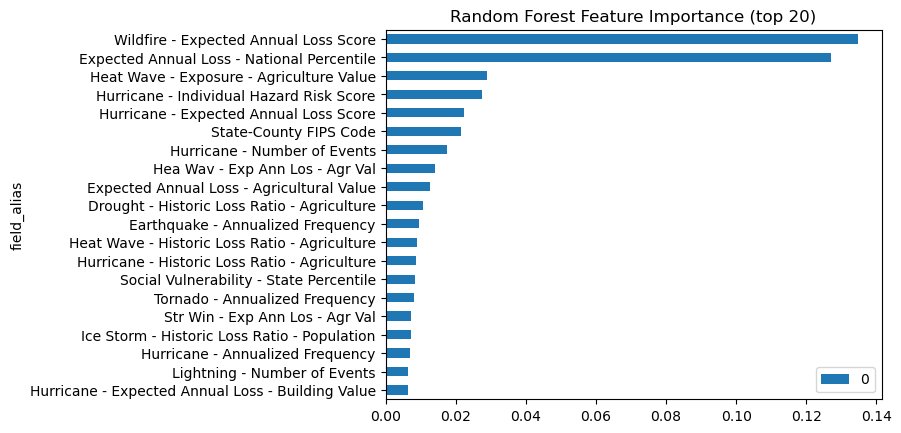

In [9]:
# ---- Global: Randomforest feature importances ----
rf_importance = pd.Series(
    getattr(model, "feature_importances_", None),
    index=getattr(
        X_train, "columns", range(len(getattr(model, "feature_importances_", [])))
    ),
)


def plot_importance(rf_importance):
    rf_importance = rf_importance.sort_values(ascending=False)

    importance = pd.DataFrame(rf_importance).reset_index()

    importance = importance.merge(
        nri_dictionary[["field_name", "field_alias"]],
        left_on="index",
        right_on="field_name",
        how="left",
    )
    importance["field_alias"] = importance["field_alias"].fillna(importance["index"])
    importance = importance.set_index("field_alias")

    display(importance.head(20))

    # plt.figure(figsize=(20, 20))
    importance.head(20).iloc[::-1].plot(kind="barh")
    plt.title("Random Forest Feature Importance (top 20)")
    # plt.tight_layout()
    plt.show()


plot_importance(rf_importance)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RandomForestRegressor Performance")
print(f"R² Score:              {r2:.3f}")
print(f"Mean Absolute Error:   {mae:.3f}")
print(f"Mean Squared Error:    {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

RandomForestRegressor Performance
R² Score:              0.678
Mean Absolute Error:   30.415
Mean Squared Error:    1825.242
Root Mean Squared Error: 42.723


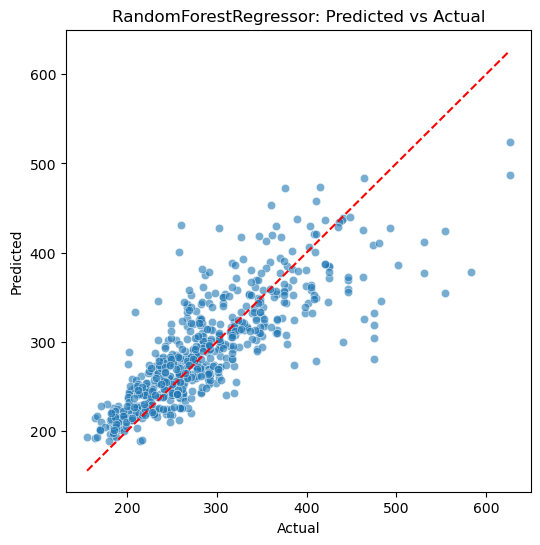

In [11]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RandomForestRegressor: Predicted vs Actual")
plt.show()

## With HPI Change

In [12]:
# Train/test split
y = targets["hpi_perc_change"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

,index,0,field_name
field_alias,,,
Earthquake - Historic Loss Ratio - Population,erqk_hlrp,0.254036,erqk_hlrp
Expected Annual Loss Rate - Building - Composite,alr_valb,0.179432,alr_valb
Hail - Annualized Frequency,hail_afreq,0.030490,hail_afreq
National Risk Index - National Percentile,risk_npctl,0.023439,risk_npctl
Hail - Number of Events,hail_evnts,0.021483,hail_evnts
Riverine Flooding - Expected Annual Loss Score,rfld_eals,0.017700,rfld_eals
Lightning - Annualized Frequency,ltng_afreq,0.017547,ltng_afreq
Lightning - Number of Events,ltng_evnts,0.015537,ltng_evnts
Exp Ann Los Rat - Nat Per - Com,alr_npctl,0.014036,alr_npctl


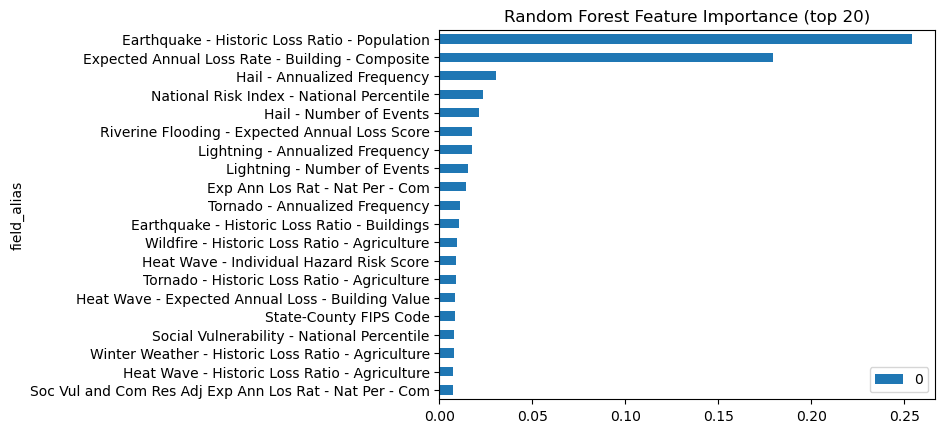

In [14]:
rf_importance = pd.Series(
    getattr(model, "feature_importances_", None),
    index=getattr(
        X_train, "columns", range(len(getattr(model, "feature_importances_", [])))
    ),
)
plot_importance(rf_importance)

In [15]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 RandomForestRegressor Performance")
print(f"R² Score:              {r2:.3f}")
print(f"Mean Absolute Error:   {mae:.3f}")
print(f"Mean Squared Error:    {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

📊 RandomForestRegressor Performance
R² Score:              0.818
Mean Absolute Error:   0.014
Mean Squared Error:    0.000
Root Mean Squared Error: 0.021


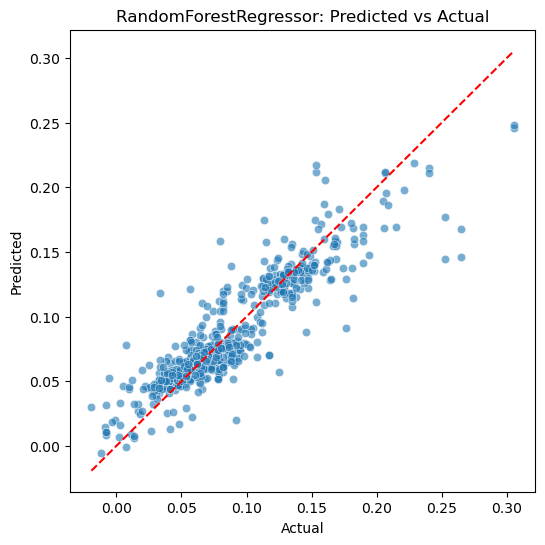

In [16]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RandomForestRegressor: Predicted vs Actual")
plt.show()

## Rerun with top 20 from all 400 columns

In [17]:
# Get one column (for example, all importance values)
df = pd.DataFrame(rf_importance).reset_index()
df.columns = ["feature", "importance"]
df = df.sort_values(by="importance", ascending=False)
df = df[df["feature"] != "risk_npctl"]
to_rerun = df.head(19)["feature"].to_list()
to_rerun

['erqk_hlrp',
 'alr_valb',
 'hail_afreq',
 'hail_evnts',
 'rfld_eals',
 'ltng_afreq',
 'ltng_evnts',
 'alr_npctl',
 'trnd_afreq',
 'erqk_hlrb',
 'wfir_hlra',
 'hwav_risks',
 'trnd_hlra',
 'hwav_ealb',
 'stcofips',
 'sovi_npctl',
 'wntw_hlra',
 'hwav_hlra',
 'alr_vra_npctl']

In [18]:
# Train/test split
X_test = X_test[to_rerun]
X_train = X_train[to_rerun]

# Train model
model_2 = RandomForestRegressor(random_state=42)
model_2.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

,index,0,field_name
field_alias,,,
Earthquake - Historic Loss Ratio - Population,erqk_hlrp,0.265988,erqk_hlrp
Expected Annual Loss Rate - Building - Composite,alr_valb,0.188520,alr_valb
Hail - Annualized Frequency,hail_afreq,0.057210,hail_afreq
Social Vulnerability - National Percentile,sovi_npctl,0.050041,sovi_npctl
State-County FIPS Code,stcofips,0.044805,stcofips
Riverine Flooding - Expected Annual Loss Score,rfld_eals,0.039256,rfld_eals
Hail - Number of Events,hail_evnts,0.038714,hail_evnts
Lightning - Annualized Frequency,ltng_afreq,0.038656,ltng_afreq
Lightning - Number of Events,ltng_evnts,0.033242,ltng_evnts


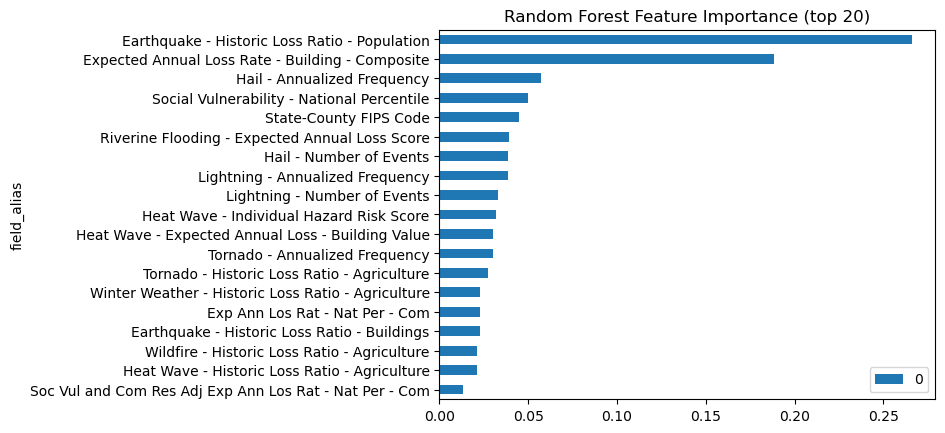

In [19]:
rf_importance = pd.Series(
    getattr(model_2, "feature_importances_", None),
    index=getattr(
        X_train, "columns", range(len(getattr(model_2, "feature_importances_", [])))
    ),
)
plot_importance(rf_importance)

In [20]:
y_pred = model_2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 RandomForestRegressor Performance")
print(f"R² Score:              {r2:.3f}")
print(f"Mean Absolute Error:   {mae:.3f}")
print(f"Mean Squared Error:    {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

📊 RandomForestRegressor Performance
R² Score:              0.832
Mean Absolute Error:   0.014
Mean Squared Error:    0.000
Root Mean Squared Error: 0.020


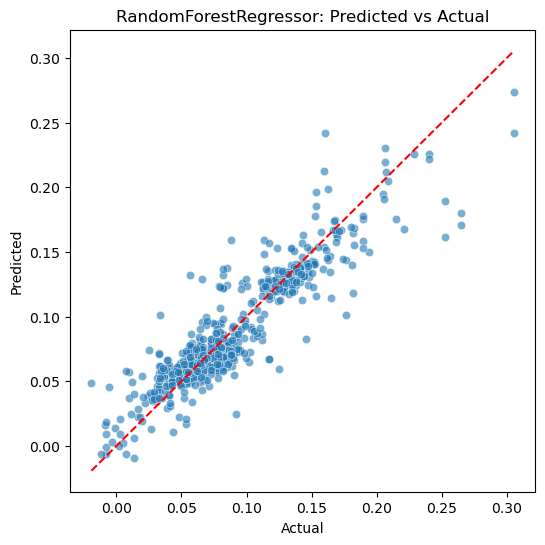

In [40]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RandomForestRegressor: Predicted vs Actual")
plt.show()

In [38]:
corr = X_train.corr(numeric_only=True)
strong_corr = corr[(corr.abs() > 0.5) & (corr.abs() < 1)]
strong_corr = strong_corr.dropna(how="all", axis=0).dropna(how="all", axis=1)

corr_merged = corr.reset_index().merge(
    nri_dictionary[["field_name", "field_alias"]],
    left_on="index",
    right_on="field_name",
    how="left",
)
corr_merged["field_alias"] = corr_merged["field_alias"].fillna(corr_merged["index"])
corr_merged = corr_merged.set_index("field_alias")
corr_merged = corr_merged.drop(columns="index")
list_field_names = nri_dictionary["field_name"].to_list()
corr_merged.columns = [
    (
        nri_dictionary.loc[nri_dictionary["field_name"] == x, "field_alias"].iloc[0]
        if x in list_field_names
        else x
    )
    for x in corr_merged.columns
]
corr_merged.drop(["field_name"], axis=1, inplace=True)
corr_merged

,Earthquake - Historic Loss Ratio - Population,Expected Annual Loss Rate - Building - Composite,Hail - Annualized Frequency,Hail - Number of Events,Riverine Flooding - Expected Annual Loss Score,Lightning - Annualized Frequency,Lightning - Number of Events,Exp Ann Los Rat - Nat Per - Com,Tornado - Annualized Frequency,Earthquake - Historic Loss Ratio - Buildings,Wildfire - Historic Loss Ratio - Agriculture,Heat Wave - Individual Hazard Risk Score,Tornado - Historic Loss Ratio - Agriculture,Heat Wave - Expected Annual Loss - Building Value,State-County FIPS Code,Social Vulnerability - National Percentile,Winter Weather - Historic Loss Ratio - Agriculture,Heat Wave - Historic Loss Ratio - Agriculture,Soc Vul and Com Res Adj Exp Ann Los Rat - Nat Per - Com
field_alias,,,,,,,,,,,,,,,,,,,
Earthquake - Historic Loss Ratio - Population,1.000000,0.052881,-0.080435,-0.078788,0.082804,-0.039897,-0.037011,0.186511,-0.066283,0.423220,-0.061010,0.137398,-0.019029,0.018704,0.011141,-0.022138,-0.019602,0.029944,0.180825
Expected Annual Loss Rate - Building - Composite,0.052881,1.000000,-0.256770,-0.274591,0.175542,0.381840,0.255879,0.725441,0.088037,0.061865,0.174161,0.020634,-0.094812,-0.026184,-0.115239,NaN,0.287190,-0.181423,0.724937
Hail - Annualized Frequency,-0.080435,-0.256770,1.000000,0.999241,-0.199659,0.221268,0.254165,-0.058042,0.850006,-0.248853,0.009349,-0.270638,-0.061395,0.091290,0.002880,-0.074562,0.107328,-0.313651,-0.101156
Hail - Number of Events,-0.078788,-0.274591,0.999241,1.000000,-0.193632,0.221139,0.259095,-0.061207,0.845065,-0.241050,0.004443,-0.263140,-0.062896,0.094124,0.001223,-0.074722,0.106864,-0.309644,-0.101617
Riverine Flooding - Expected Annual Loss Score,0.082804,0.175542,-0.199659,-0.193632,1.000000,0.047316,-0.001557,0.131267,-0.198201,0.399815,0.029871,0.684243,-0.134820,0.059825,-0.006129,0.048776,0.093836,0.021143,0.126671
Lightning - Annualized Frequency,-0.039897,0.381840,0.221268,0.221139,0.047316,1.000000,0.973492,0.364635,0.238347,-0.044694,0.248347,0.043961,-0.070955,0.047701,-0.257377,0.023567,0.320985,-0.552060,0.365514
Lightning - Number of Events,-0.037011,0.255879,0.254165,0.259095,-0.001557,0.973492,1.000000,0.305290,0.267087,-0.041851,0.246218,0.003503,-0.067235,0.051371,-0.262954,0.023576,0.312160,-0.558858,0.308445
Exp Ann Los Rat - Nat Per - Com,0.186511,0.725441,-0.058042,-0.061207,0.131267,0.364635,0.305290,1.000000,0.214021,0.263182,-0.015611,0.098246,-0.076234,0.026830,-0.209880,NaN,0.328263,-0.273272,0.982807
Tornado - Annualized Frequency,-0.066283,0.088037,0.850006,0.845065,-0.198201,0.238347,0.267087,0.214021,1.000000,-0.255972,0.087664,-0.329031,-0.136712,0.012857,-0.087161,-0.031094,0.258279,-0.222460,0.203811


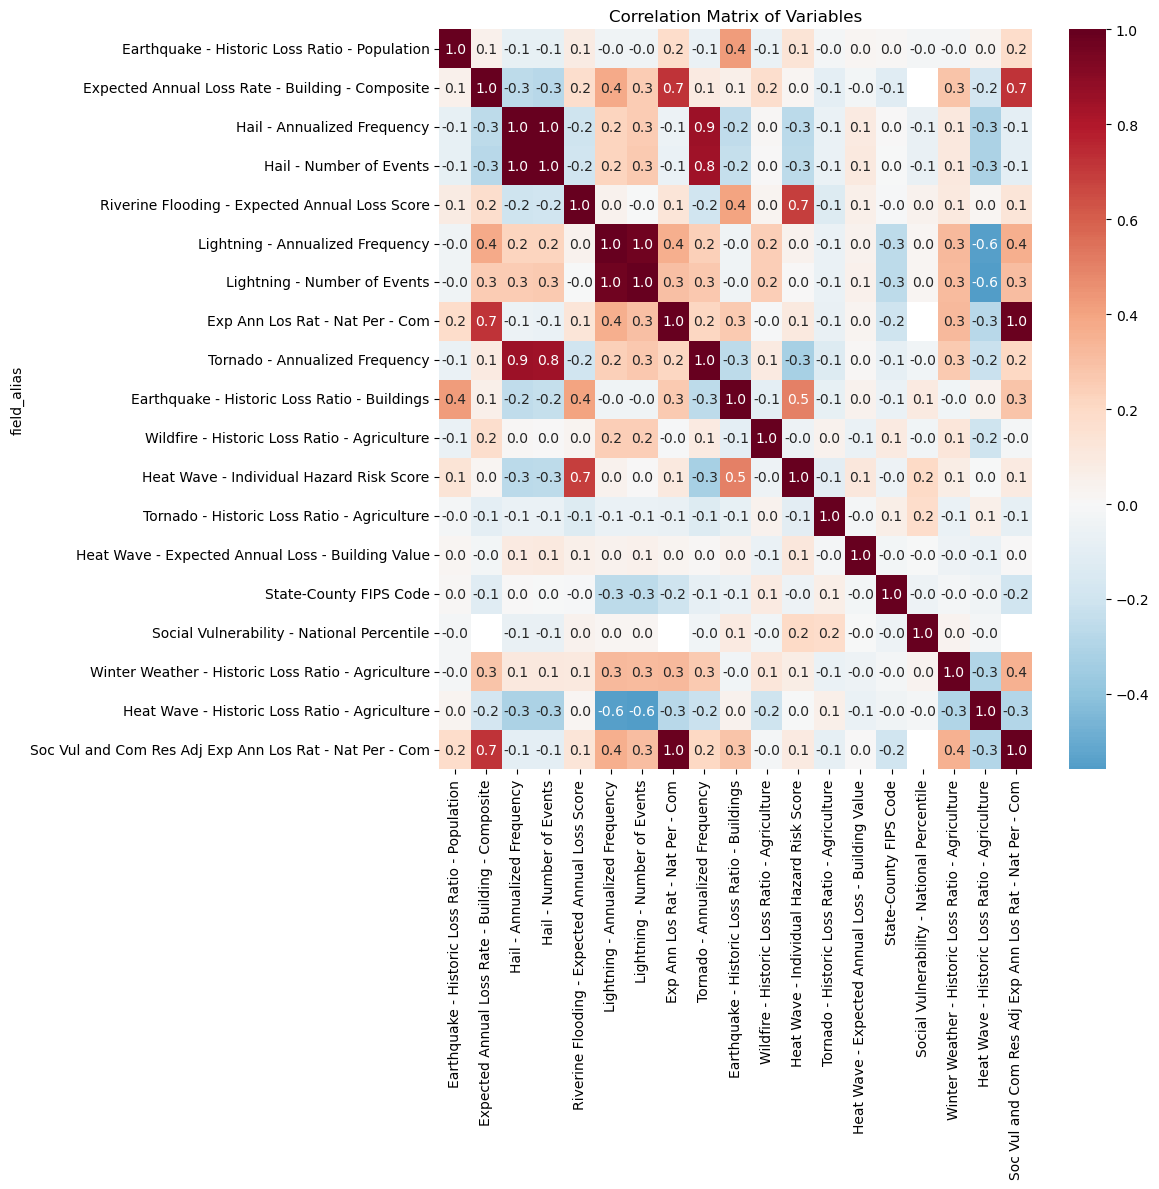

In [39]:
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_merged,
    # .drop(
    #     columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    # ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

## Geospatial

In [ ]:
import geopandas as gpd

geo = gpd.read_file(
    "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
)
geo = geo.merge(pd.DataFrame(rf_importance).reset_index(), on="stcofips")
geo.plot(column="predicted_hpi", cmap="RdYlBu", legend=True)

DataSourceError: '/vsizip/vsicurl/https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip' does not exist in the file system, and is not recognized as a supported dataset name.

## PCA

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [22]:
nri_hpi = nri_hpi.fillna(0)
scaler = StandardScaler()
nri_hpi_model = scaler.fit_transform(nri_hpi)

In [23]:
pca = PCA(n_components=40)  # keep 2 principal components
X_pca = pca.fit_transform(nri_hpi_model)

In [24]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.1564853  0.09706085 0.05873917 0.04131179 0.03376321 0.02896663
 0.02317497 0.02302098 0.02110919 0.01743159 0.01638321 0.01482341
 0.01438195 0.0133454  0.01240213 0.01163469 0.01078256 0.01050958
 0.00972902 0.00950385 0.00880663 0.00841447 0.007973   0.00779959
 0.00760072 0.00731471 0.00699883 0.00683567 0.00676029 0.00644933
 0.00613374 0.00597537 0.00591304 0.00553931 0.00539267 0.00531058
 0.00520549 0.00489302 0.00482647 0.00479532]
Cumulative: 0.7534977584348908


In [25]:
pca_df = pd.DataFrame(
    X_pca  # , columns=["PC1", "PC2", "PC3", "PC4","PC5","PC6","PC7","PC8","PC9","PC10","PC11","PC12","PC13","PC14","PC15","PC16","PC17","PC18","PC19","PC20","PC21","PC22","PC23","PC24","PC25",], index=nri_hpi.index
)
pca_df = pd.concat([pca_df, nri_hpi[["stcofips"]]], axis=1)
pca_df

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,stcofips
0,2.095638,6.287367,-0.913490,1.740107,-1.578670,-0.912313,-1.323138,-1.743422,0.333398,-0.264117,...,0.761912,-0.403332,0.353311,-0.667686,1.662239,0.429252,1.144218,0.277013,0.673150,1001
1,15.186869,5.979872,-5.245372,15.845957,1.095633,2.438311,-1.969339,0.885978,2.478622,-4.029153,...,-2.527462,-1.465006,-1.641268,2.941586,-2.068530,3.853284,0.347717,-1.164477,-0.976991,1003
2,1.288241,7.813818,-0.492421,1.774224,-1.579423,-0.962943,-1.246249,-1.432933,0.969653,1.076858,...,0.140832,-0.236164,1.646406,-0.152968,1.386001,-0.222178,1.411701,0.585286,1.040142,1007
3,4.070207,8.323498,-1.246452,0.170439,-1.985537,-1.465611,-0.989249,-0.128126,0.182760,-0.464439,...,-0.027970,-0.649463,1.227053,0.265284,2.360588,1.454236,1.537521,-0.662717,0.922660,1009
4,6.574429,7.396554,-1.413702,0.199722,-0.940057,-1.808065,-1.200169,-1.328478,0.799560,-0.424908,...,0.295102,-0.307493,0.507899,-0.745691,2.467125,1.393127,2.152091,-0.619559,2.077997,1015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,-4.454669,-3.446511,-1.068790,-2.277359,0.727729,0.530965,0.521890,1.090027,0.284449,0.204851,...,-0.222288,0.777079,-1.354662,-0.095339,-0.100896,0.688733,-0.026540,-0.142828,-1.004880,55131
3113,0.089251,-6.892236,-2.829516,-3.893122,2.056741,0.681475,0.820534,0.550213,0.536323,-0.937875,...,-1.220286,1.053481,-0.714187,0.463903,-0.944174,0.550833,-0.358367,-0.539909,0.208282,55133
3114,-3.959391,-3.999927,-1.910793,-2.992352,1.223545,0.710555,0.814385,1.703898,1.272870,-0.781895,...,1.558059,0.303644,-1.588798,-0.284141,0.038565,1.311770,-0.389025,-1.240216,-2.394722,55139
3115,-4.426690,-2.967346,-0.038621,-3.374502,1.814745,4.030968,3.096916,4.050691,0.718321,-0.729557,...,0.313302,-0.672786,-0.778191,1.227267,1.653280,2.281895,1.632256,-2.736721,1.668442,56021


In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="stcofips", alpha=0.7)
plt.title("PCA of Risk and HPI Features")
plt.show()

ValueError: Could not interpret value `PC1` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)
print(loadings)

                 PC1       PC2       PC3       PC4       PC5       PC6  \
statefips  -0.008652  0.003774 -0.010979 -0.019946  0.068987 -0.018691   
countyfips -0.005085  0.003129 -0.027924  0.010635 -0.003077 -0.007849   
stcofips   -0.008678  0.003792 -0.011183 -0.019830  0.068852 -0.018723   
population  0.087971 -0.101403  0.002617 -0.019228 -0.016817 -0.005937   
buildvalue  0.100898 -0.086984  0.003953 -0.022708 -0.017169 -0.009373   
...              ...       ...       ...       ...       ...       ...   
eal_npctl  -0.050236 -0.112401 -0.008324 -0.009524  0.008786  0.006346   
sovi_npctl -0.048741 -0.075578 -0.005310  0.014828 -0.016327  0.004949   
sovi_value  0.023547  0.022790 -0.001344  0.018862 -0.017122 -0.014546   
resl_npctl -0.065989 -0.090626 -0.023679 -0.020364  0.003917  0.005135   
yr          0.079554  0.109614  0.008287  0.009868 -0.001993 -0.020722   

                 PC7       PC8       PC9      PC10  ...      PC31      PC32  \
statefips  -0.019617 -0.054930 -

Explained variance ratio: [0.1564853  0.09706085 0.05873917 0.04131179 0.03376321 0.02896663
 0.02317497 0.02302098 0.02110919 0.01743159 0.01638321 0.01482341
 0.01438195 0.0133454  0.01240213 0.01163469 0.01078256 0.01050958
 0.00972902 0.00950385 0.00880663 0.00841447 0.007973   0.00779959
 0.00760072 0.00731471 0.00699883 0.00683567 0.00676029 0.00644933
 0.00613374 0.00597537 0.00591304 0.00553931 0.00539267 0.00531058
 0.00520549 0.00489302 0.00482647 0.00479532]
Cumulative variance explained: [0.1564853  0.25354615 0.31228533 0.35359711 0.38736033 0.41632696
 0.43950193 0.46252291 0.4836321  0.50106369 0.5174469  0.53227031
 0.54665227 0.55999767 0.5723998  0.58403449 0.59481705 0.60532664
 0.61505565 0.6245595  0.63336613 0.6417806  0.6497536  0.65755319
 0.6651539  0.67246861 0.67946745 0.68630312 0.69306341 0.69951274
 0.70564648 0.71162185 0.71753489 0.7230742  0.72846687 0.73377745
 0.73898295 0.74387597 0.74870244 0.75349776]


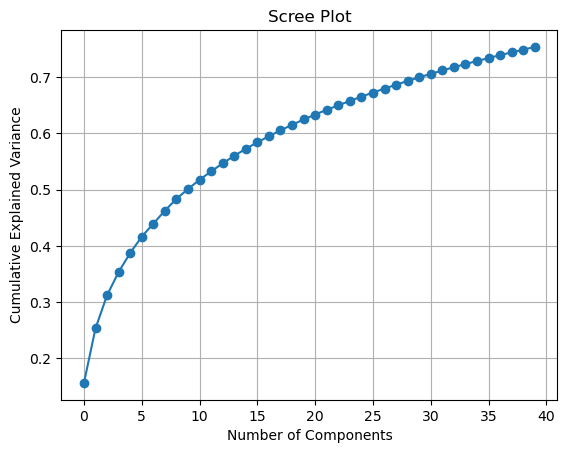

In [28]:
# After fitting PCA
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained:", np.cumsum(pca.explained_variance_ratio_))

# Scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

cfld_ealt     2.507465
cfld_ealb     2.346276
lnds_ealpe    2.294827
lnds_ealp     2.282208
cfld_ealp     2.271585
cfld_ealpe    2.268168
sovi_value    2.265042
hwav_ealpe    2.187004
lnds_ealt     2.184202
hwav_ealt     2.180616
dtype: float64


,index,0,field_name
field_alias,,,
Coastal Flooding - Expected Annual Loss - Total,cfld_ealt,2.507465,cfld_ealt
Coa Flo - Exp Ann Los - Bui Val,cfld_ealb,2.346276,cfld_ealb
Lan - Exp Ann Los - Pop Equ,lnds_ealpe,2.294827,lnds_ealpe
Landslide - Expected Annual Loss - Population,lnds_ealp,2.282208,lnds_ealp
Coa Flo - Exp Ann Los - Pop,cfld_ealp,2.271585,cfld_ealp
Coa Flo - Exp Ann Los - Pop Equ,cfld_ealpe,2.268168,cfld_ealpe
Social Vulnerability - Value,sovi_value,2.265042,sovi_value
Hea Wav - Exp Ann Los - Pop Equ,hwav_ealpe,2.187004,hwav_ealpe
Landslide - Expected Annual Loss - Total,lnds_ealt,2.184202,lnds_ealt


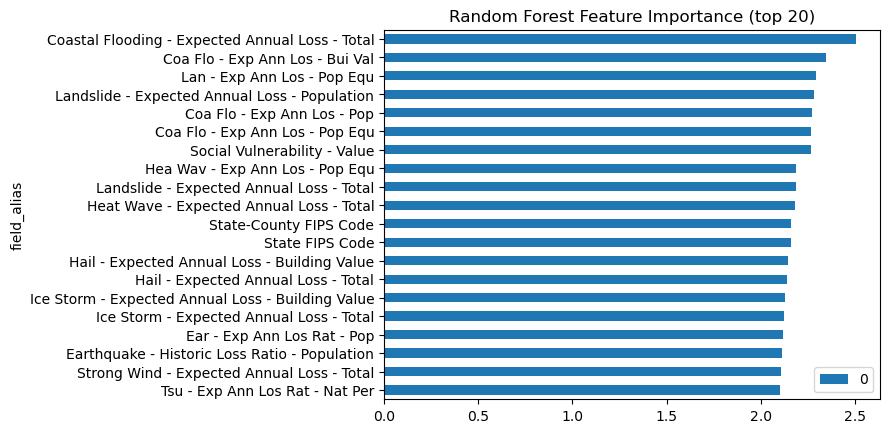

In [29]:
important_features = (
    loadings.abs()
    .sum(axis=1)  # total contribution across PCs
    .sort_values(ascending=False)
)
# important_features = pd.DataFrame(important_features).reset_index()
print(important_features.head(10))
plot_importance(important_features)

In [ ]:
corr = nri_hpi.corr(numeric_only=True)
print(corr)

               statefips    countyfips      stcofips  population  buildvalue  \
statefips   1.000000e+00  1.991630e-01  9.999699e-01   -0.078511   -0.071060   
countyfips  1.991630e-01  1.000000e+00  2.067547e-01   -0.046287   -0.050202   
stcofips    9.999699e-01  2.067547e-01  1.000000e+00   -0.078751   -0.071343   
population -7.851119e-02 -4.628658e-02 -7.875131e-02    1.000000    0.958157   
buildvalue -7.105953e-02 -5.020157e-02 -7.134260e-02    0.958157    1.000000   
...                  ...           ...           ...         ...         ...   
eal_npctl  -6.863862e-02 -9.219505e-03 -6.860134e-02    0.176009    0.032963   
sovi_npctl -2.725986e-02  7.406025e-02 -2.663016e-02    0.028784   -0.073917   
sovi_value -2.610429e-02  8.886455e-02 -2.535933e-02    0.053242    0.059349   
resl_npctl  5.242370e-02 -6.698587e-03  5.228652e-02   -0.039811   -0.124437   
yr          8.346983e-15 -2.496233e-15  1.099436e-14    0.021562    0.146273   

            agrivalue      area  risk_v

In [ ]:
strong_corr = corr[(corr.abs() > 0.5) & (corr.abs() < 1)]
strong_corr = strong_corr.dropna(how="all", axis=0).dropna(how="all", axis=1)

print(strong_corr.dropna(how="all", axis=0).dropna(how="all", axis=1).reset_index())

          index  statefips  stcofips  population  buildvalue  agrivalue  area  \
0     statefips        NaN   0.99997         NaN         NaN        NaN   NaN   
1      stcofips    0.99997       NaN         NaN         NaN        NaN   NaN   
2    population        NaN       NaN         NaN    0.958157        NaN   NaN   
3    buildvalue        NaN       NaN    0.958157         NaN        NaN   NaN   
4     agrivalue        NaN       NaN         NaN         NaN        NaN   NaN   
..          ...        ...       ...         ...         ...        ...   ...   
359   eal_npctl        NaN       NaN         NaN         NaN        NaN   NaN   
360  sovi_npctl        NaN       NaN         NaN         NaN        NaN   NaN   
361  sovi_value        NaN       NaN         NaN         NaN        NaN   NaN   
362  resl_npctl        NaN       NaN         NaN         NaN        NaN   NaN   
363          yr        NaN       NaN         NaN         NaN        NaN   NaN   

     risk_value  risk_score

In [ ]:
"statefips" in nri_dictionary["field_name"].to_list()

True

In [ ]:
corr_merged = corr.reset_index().merge(
    nri_dictionary[["field_name", "field_alias"]],
    left_on="index",
    right_on="field_name",
    how="left",
)
corr_merged["field_alias"] = corr_merged["field_alias"].fillna(corr_merged["index"])
corr_merged = corr_merged.set_index("field_alias")
corr_merged = corr_merged.drop(columns="index")
list_field_names = nri_dictionary["field_name"].to_list()
corr_merged.columns = [
    (
        nri_dictionary.loc[nri_dictionary["field_name"] == x, "field_alias"].iloc[0]
        if x in list_field_names
        else x
    )
    for x in corr_merged.columns
]
corr_merged

,State FIPS Code,County FIPS Code,State-County FIPS Code,Population (2016),Building Value ($),Agricultural Value ($),Area (sq mi),National Risk Index - Value - Composite,National Risk Index - Score,National Risk Index - State Percentile,...,Winter Weather - Hazard Type Risk Index Value,Winter Weather - Individual Hazard Risk Score,NRI Version,National Risk Index - National Percentile,Expected Annual Loss - National Percentile,Social Vulnerability - National Percentile,Social Vulnerability - Value,Community Resilience - National Percentile,yr,field_name
field_alias,,,,,,,,,,,,,,,,,,,,,
State FIPS Code,1.000000e+00,1.991630e-01,9.999699e-01,-0.078511,-0.071060,-0.177068,-0.163476,-0.057234,-0.077240,-0.004673,...,0.034604,0.090457,8.346983e-15,-0.071011,-0.068639,-0.027260,-0.026104,0.052424,8.346983e-15,statefips
County FIPS Code,1.991630e-01,1.000000e+00,2.067547e-01,-0.046287,-0.050202,-0.074612,-0.108287,-0.011136,-0.017123,0.062604,...,0.051202,0.033556,-2.496233e-15,0.022712,-0.009220,0.074060,0.088865,-0.006699,-2.496233e-15,countyfips
State-County FIPS Code,9.999699e-01,2.067547e-01,1.000000e+00,-0.078751,-0.071343,-0.177374,-0.164070,-0.057230,-0.077251,-0.004170,...,0.034954,0.090577,1.099436e-14,-0.070717,-0.068601,-0.026630,-0.025359,0.052287,1.099436e-14,stcofips
Population (2016),-7.851119e-02,-4.628658e-02,-7.875131e-02,1.000000,0.958157,0.200010,0.293848,0.441647,0.259171,0.366030,...,0.101364,0.101460,2.156188e-02,0.201635,0.176009,0.028784,0.053242,-0.039811,2.156188e-02,population
Building Value ($),-7.105953e-02,-5.020157e-02,-7.134260e-02,0.958157,1.000000,0.191888,0.259321,0.564505,0.381650,0.375285,...,0.179400,0.198622,1.462729e-01,0.060583,0.032963,-0.073917,0.059349,-0.124437,1.462729e-01,buildvalue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Expected Annual Loss - National Percentile,-6.863862e-02,-9.219505e-03,-6.860134e-02,0.176009,0.032963,0.032655,0.054473,-0.208152,-0.588000,0.209270,...,-0.268574,-0.511425,-7.718589e-01,0.901468,1.000000,0.529261,-0.181790,0.704675,-7.718589e-01,eal_npctl
Social Vulnerability - National Percentile,-2.725986e-02,7.406025e-02,-2.663016e-02,0.028784,-0.073917,-0.006220,0.054338,-0.163817,-0.444579,0.216705,...,-0.211369,-0.383024,-6.041247e-01,0.746801,0.529261,1.000000,0.561997,0.357129,-6.041247e-01,sovi_npctl
Social Vulnerability - Value,-2.610429e-02,8.886455e-02,-2.535933e-02,0.053242,0.059349,0.056361,0.079126,0.059530,0.296738,0.426658,...,0.076810,0.241714,2.195343e-01,0.197649,-0.181790,0.561997,1.000000,-0.372478,2.195343e-01,sovi_value


In [ ]:
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_merged.drop(
        columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

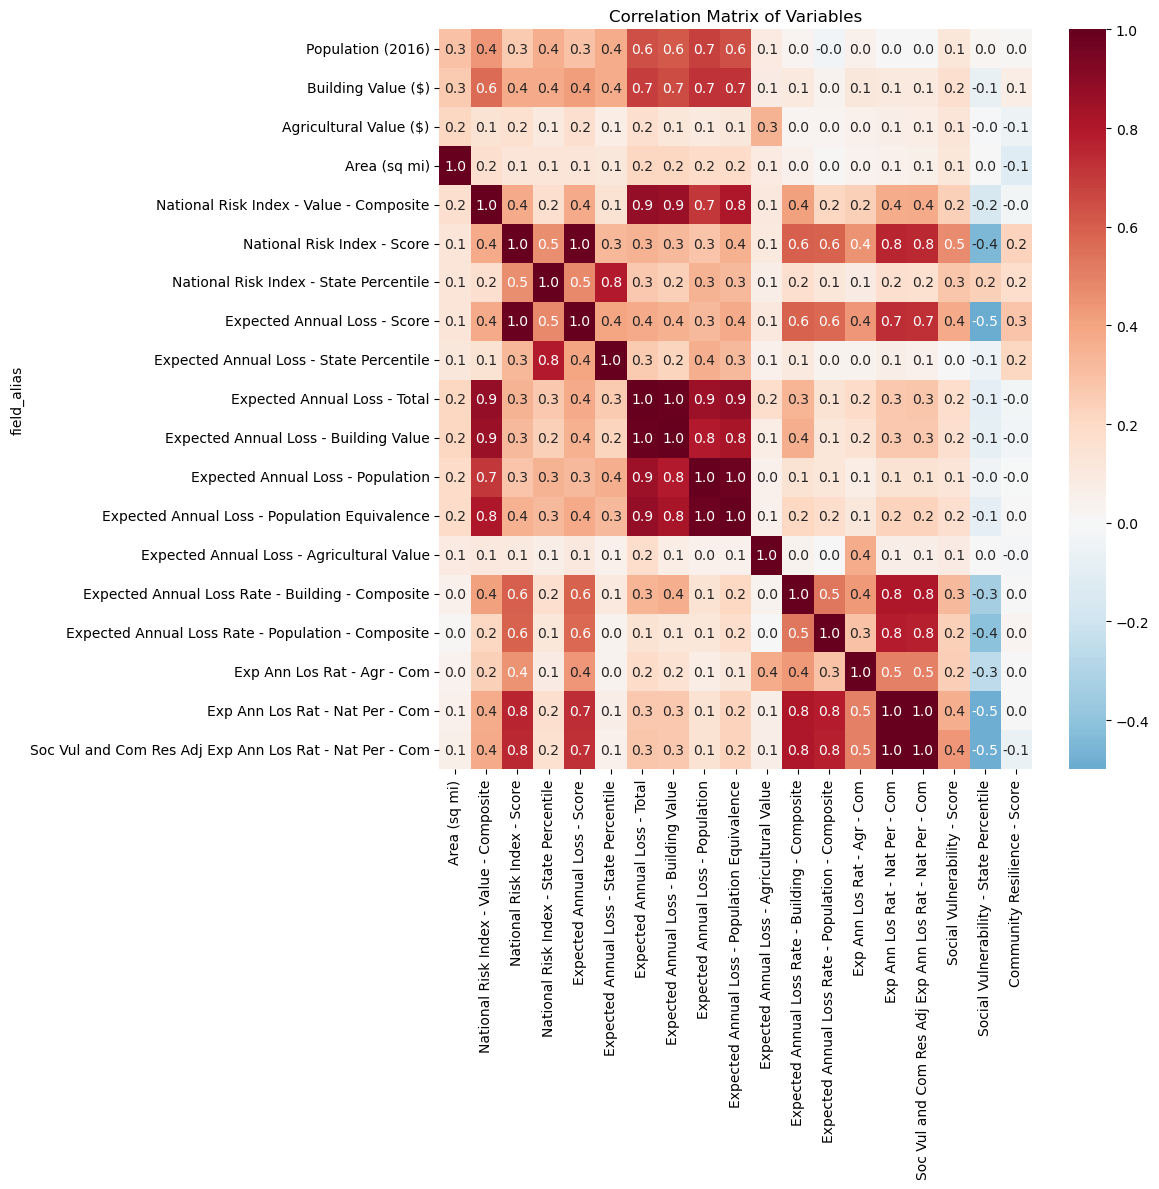

In [ ]:
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_merged.drop(
        columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

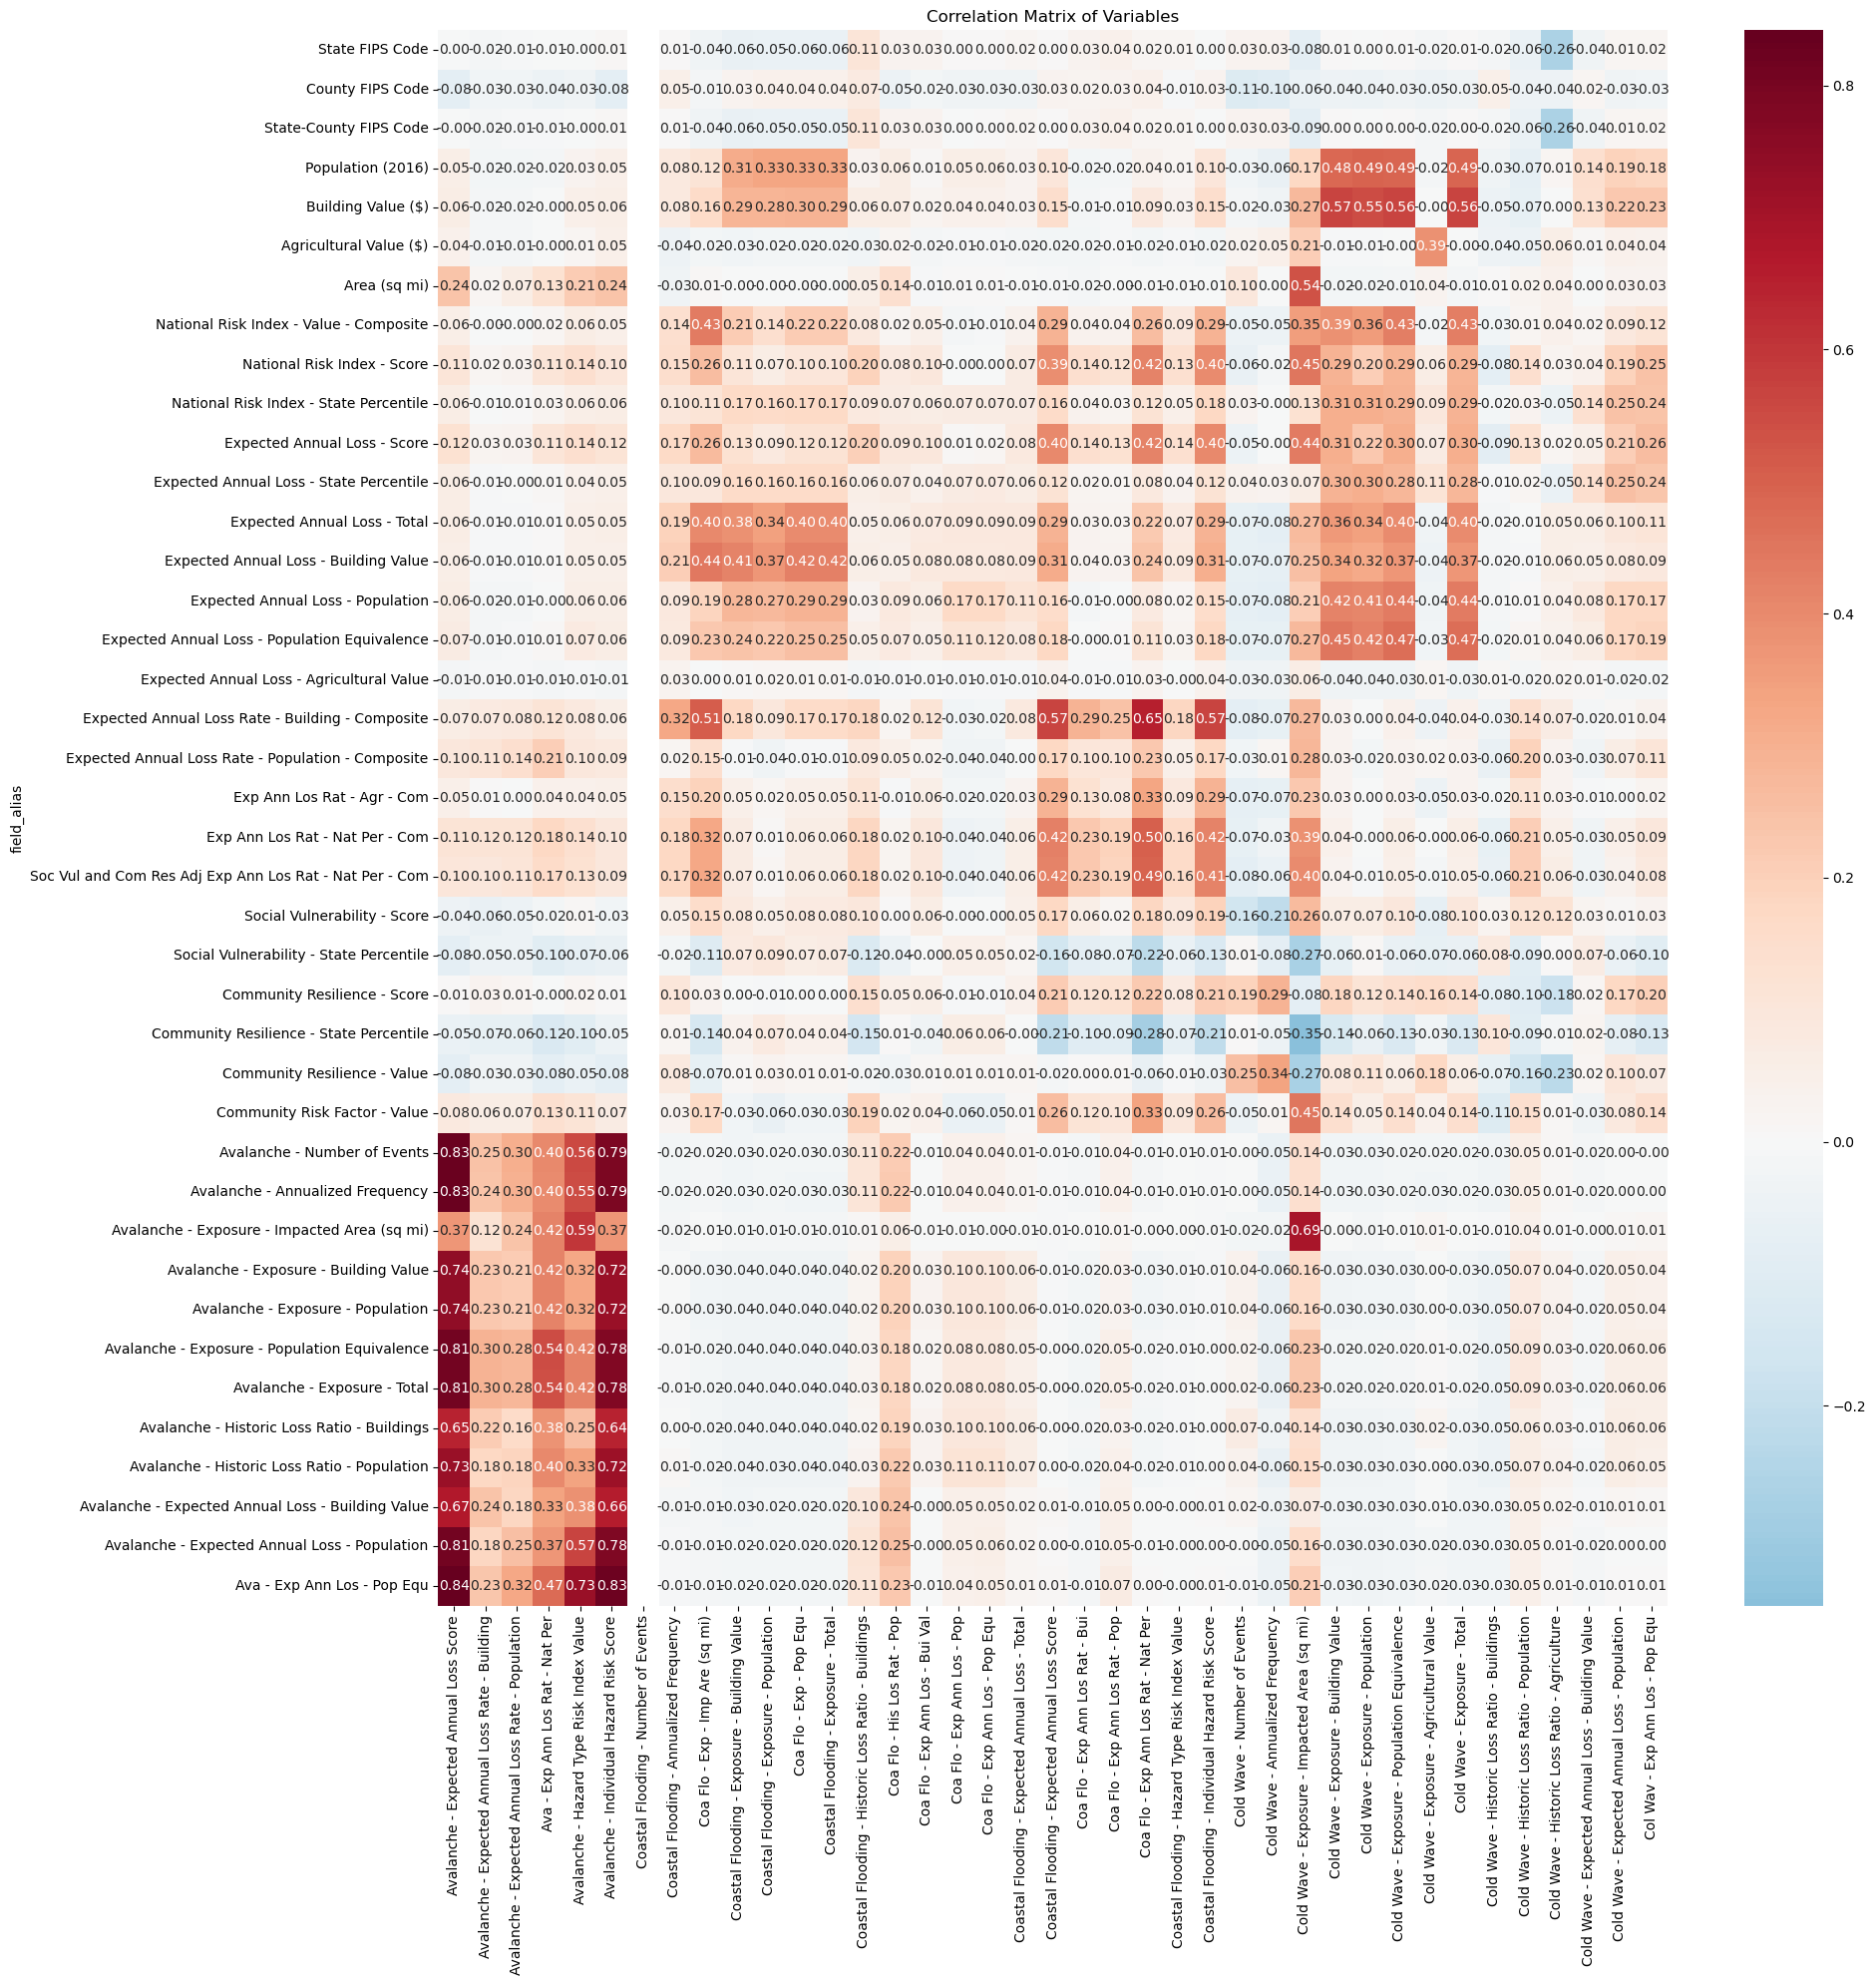

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_merged.iloc[:40, 41:80], annot=True, cmap="RdBu_r", center=0, fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

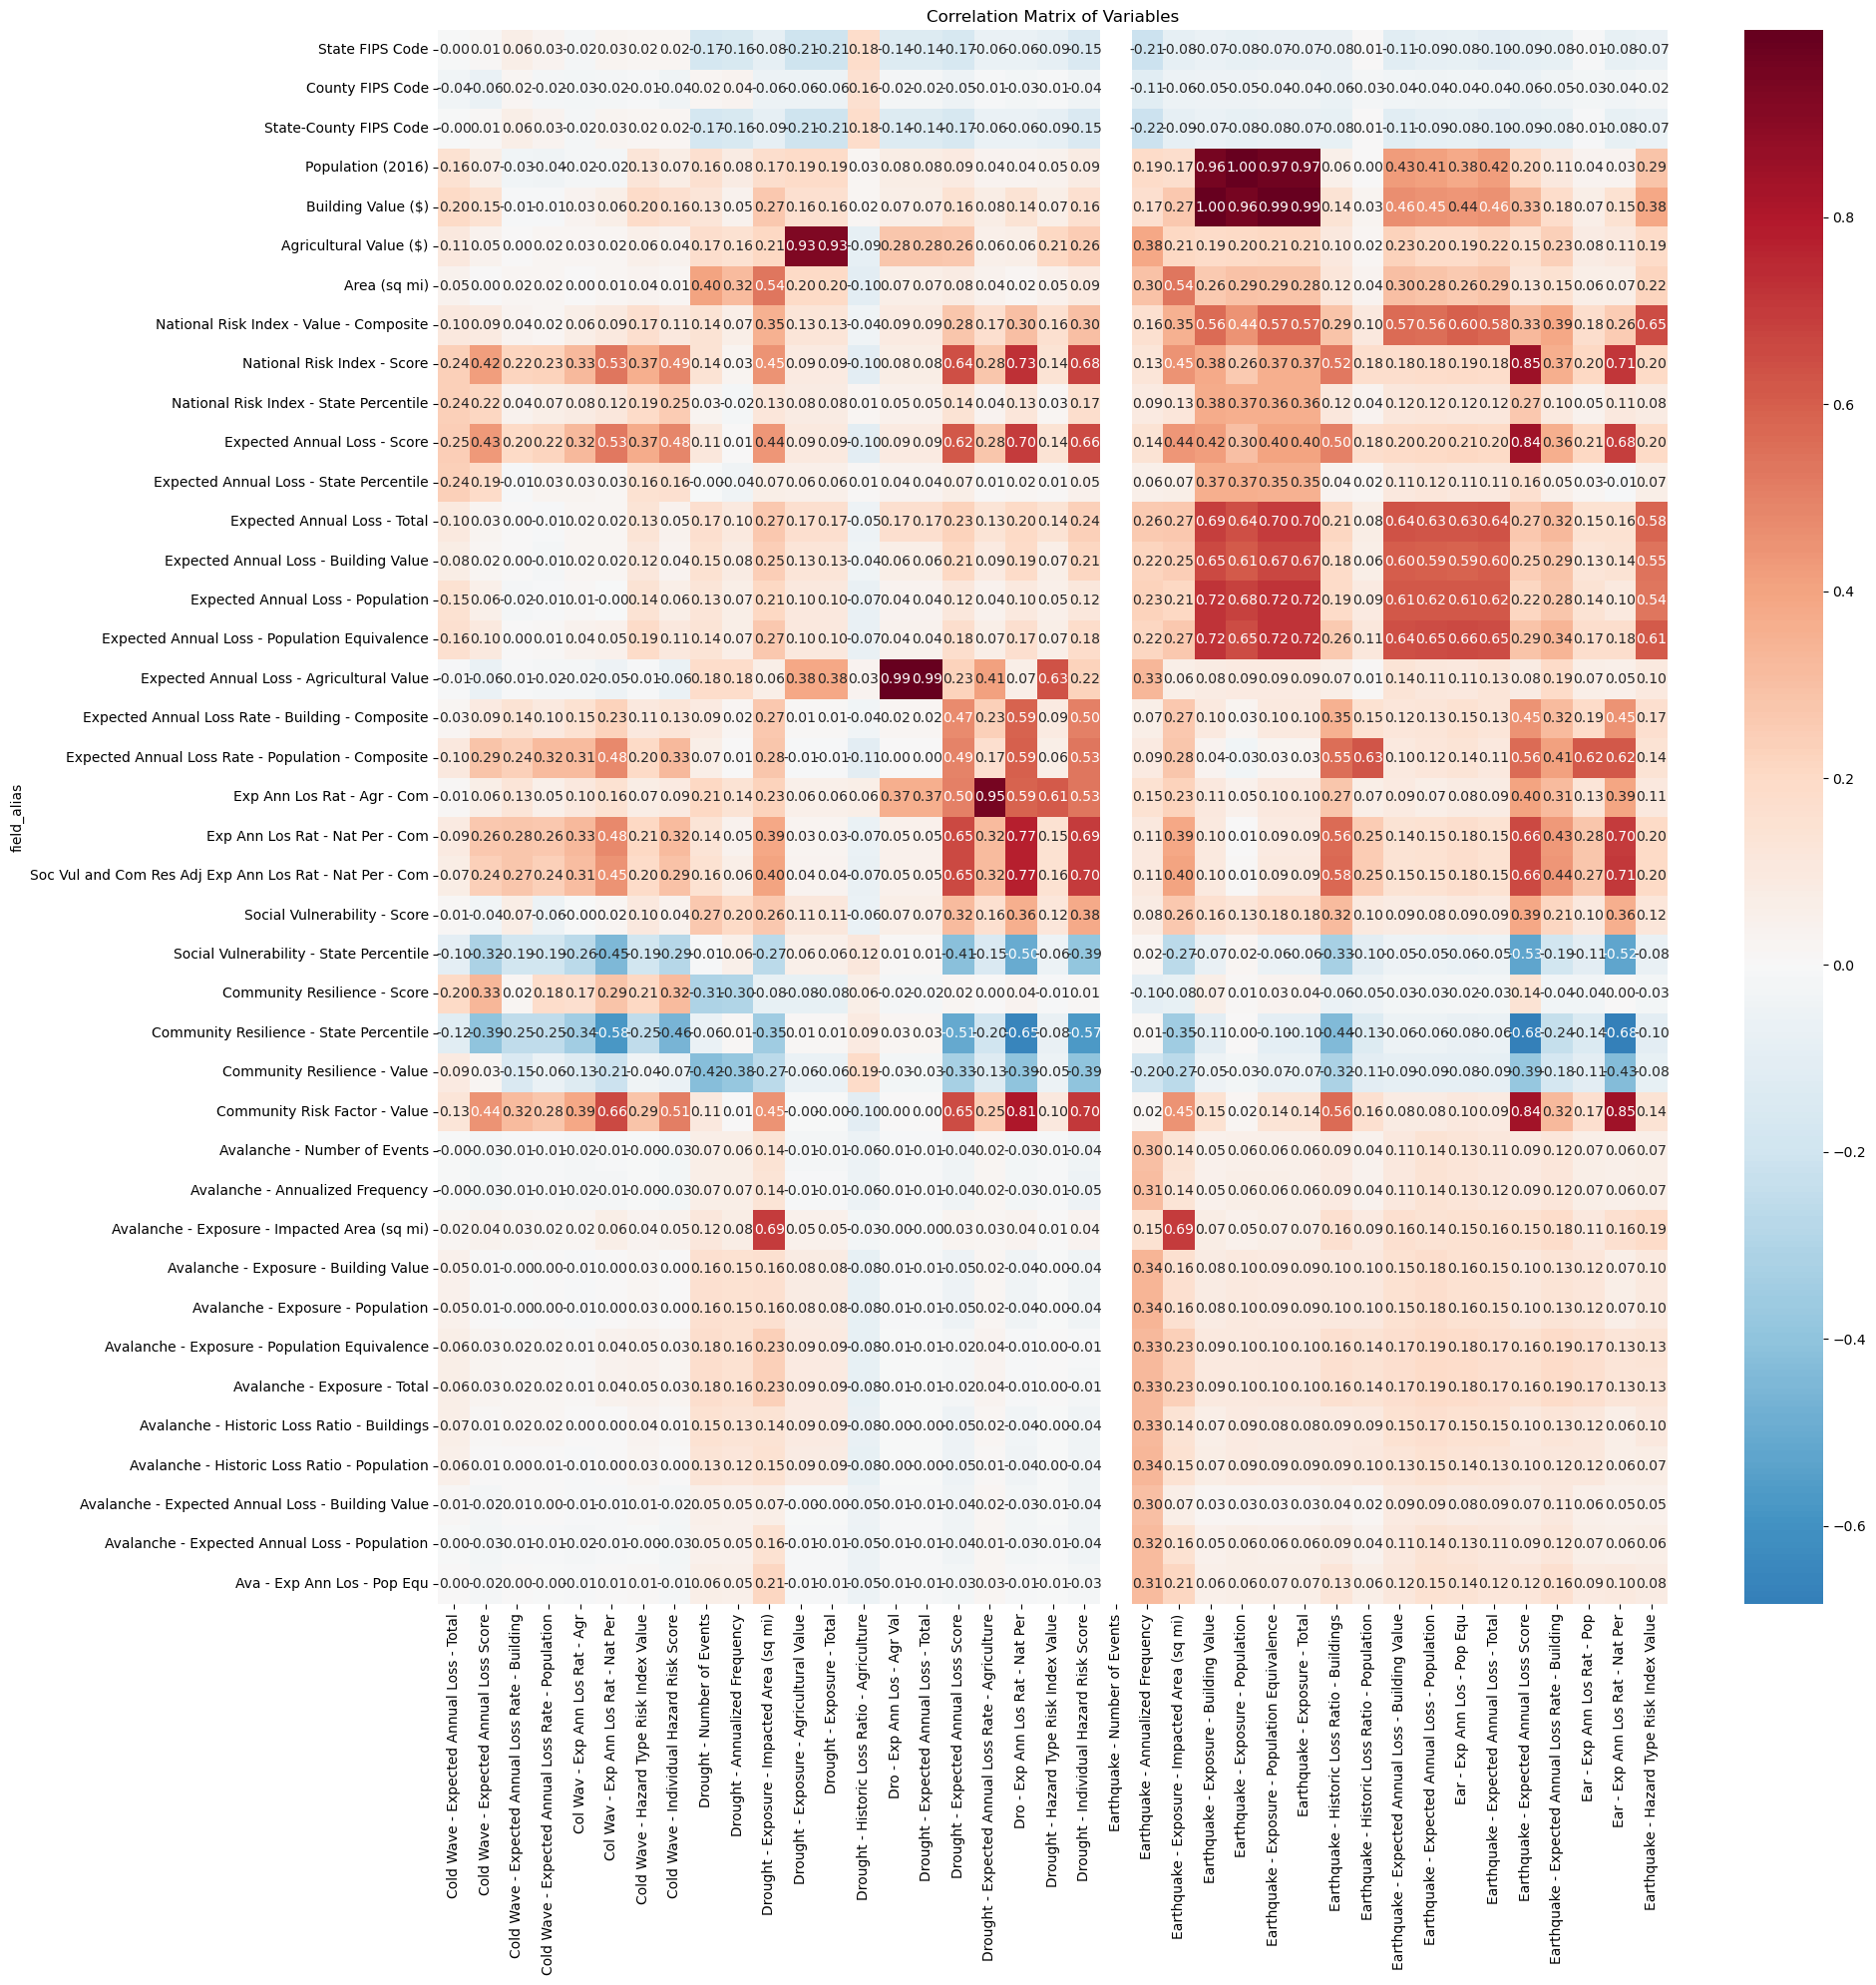

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_merged.iloc[:40, 81:120], annot=True, cmap="RdBu_r", center=0, fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

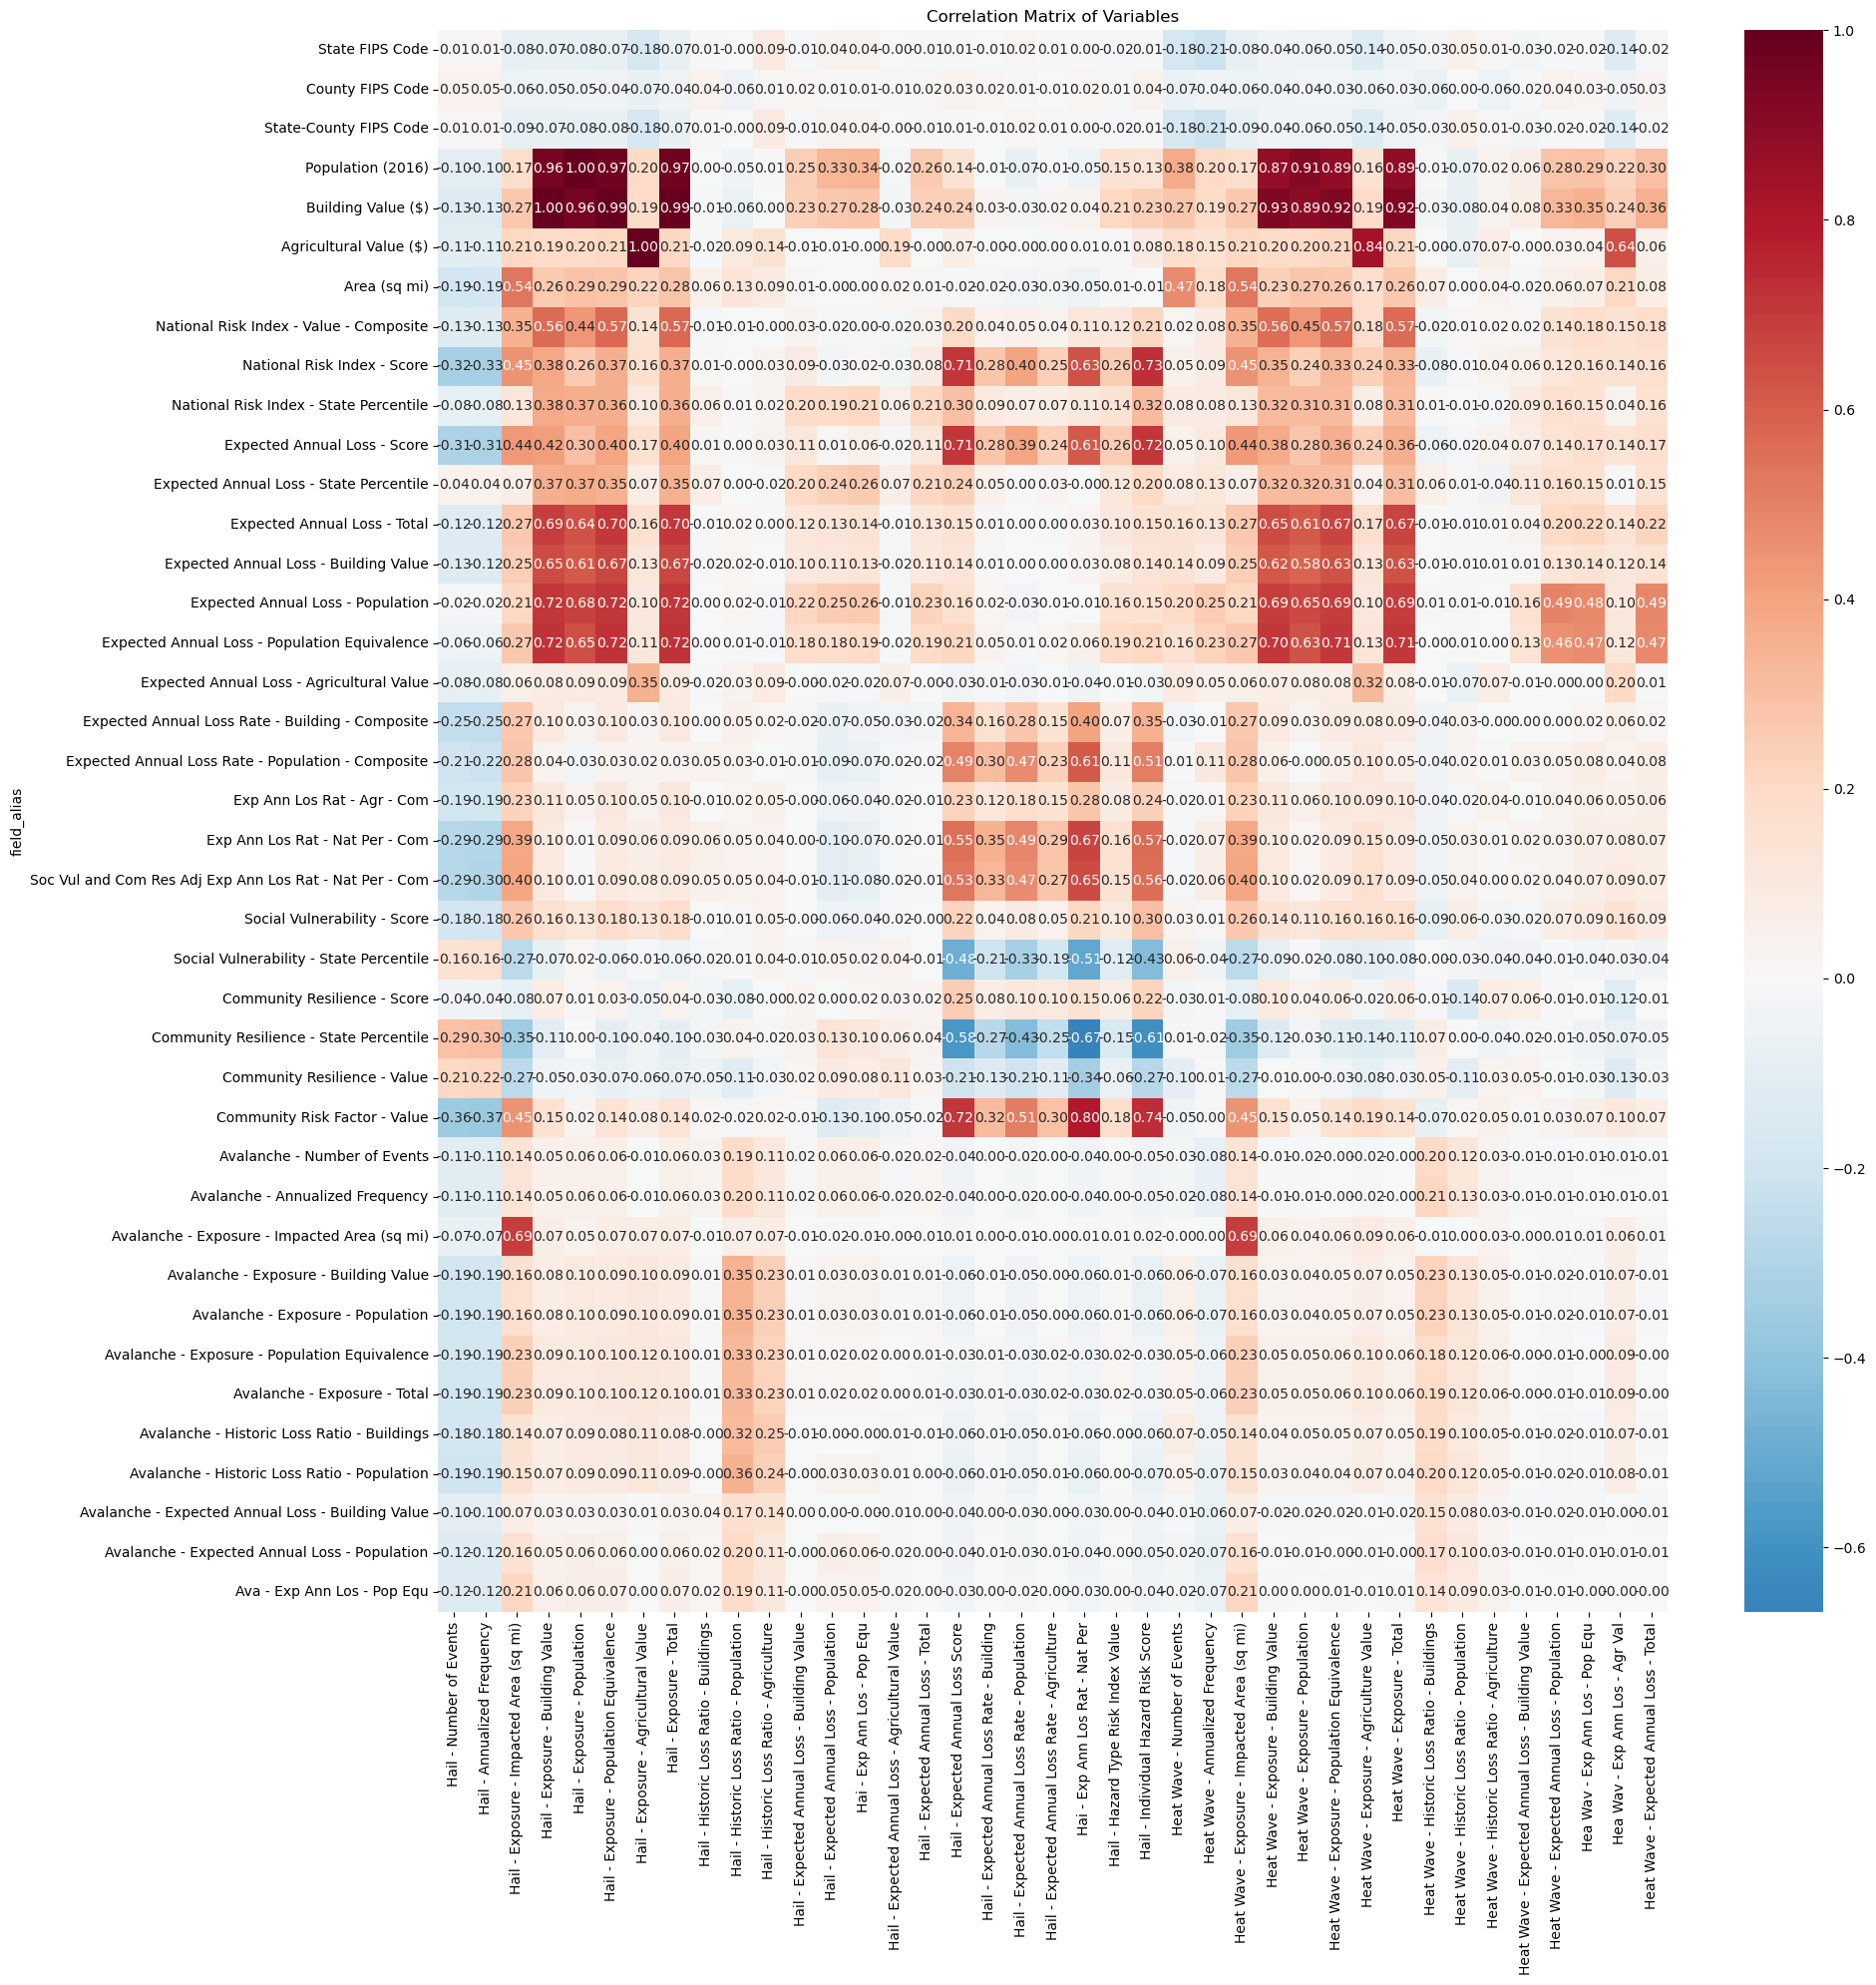

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_merged.iloc[:40, 121:160], annot=True, cmap="RdBu_r", center=0, fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

X = nri_hpi.select_dtypes(include="number").dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

labels = nri_hpi["state"] if "state" in nri_hpi.columns else None

tsne = TSNE(
    n_components=2,  # 2D output
    perplexity=30,  # typical: 5–50 (tunes local/global balance)
    n_iter=1000,  # number of optimization iterations
    random_state=42,
    learning_rate="auto",
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])

X_pca = PCA(n_components=30).fit_transform(X_scaled)
X_tsne = TSNE(
    n_components=2, perplexity=40, n_iter=1000, random_state=42
).fit_transform(X_pca)


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df, x="TSNE1", y="TSNE2", hue="label", palette="tab10", alpha=0.7
)
plt.title("t-SNE Visualization of Features")
plt.show()

ValueError: Found array with 0 sample(s) (shape=(0, 407)) while a minimum of 1 is required by StandardScaler.